# Imports

In [47]:
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

from src.data_topic import (
    load_documents,
    build_topic_dataframe,
    stratified_split_topic,
    build_vocab,
    encode_tokens,
    build_label_mapping,
    PAD_TOKEN,
    UNK_TOKEN,
    CLS_TOKEN
)

print("Part 3 imports loaded successfully.")

Part 3 imports loaded successfully.


In [48]:
import importlib
import src.train_eval_topic

importlib.reload(src.train_eval_topic)

from src.train_eval_topic import (
    LabelSmoothingCrossEntropy,
    train_topic_classifier,
    evaluate_topic_classifier,
    plot_topic_training_history,
    get_topic_confusion_matrix,
    attention_matrix_for_sample,
    train_topic_classifier_simple_ce,
    evaluate_topic_classifier_non_transformer
)

print("train_eval_topic reloaded successfully.")

train_eval_topic reloaded successfully.


# paths and device

In [49]:
BASE_DIR = "."
CLEANED_PATH = os.path.join(BASE_DIR, "cleaned.txt")
META_PATH = os.path.join(BASE_DIR, "metadata.json")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## load documents

In [50]:
docs = load_documents(CLEANED_PATH, META_PATH)
topic_df = build_topic_dataframe(docs, min_len=20)

print("Documents loaded:", len(docs))
print("Usable topic-classification documents:", len(topic_df))
display(topic_df.head())

Documents loaded: 210
Usable topic-classification documents: 210


,doc_id,title,tokens,topic
0,1,پنجاب کے ہسپتالوں میں ایمرجنسی میں کام کرنے وا...,"[پاکستان, کے, صوبے, پنجاب, کی, وزیر, اعلی, مری...",health_society
1,2,’قیمتی خزانہ‘ سونپنے کے لیے ’صحیح شخص‘ کی تلاش...,"[،تصویر, کا, ذریعہ, راولپنڈی, سے, تعلق, رکھنے,...",economy
2,3,گرمجوشی، مصافحہ اور طویل انتظار: ترکمانستان می...,"[،تصویر, کا, ذریعہ, پاکستان, کے, وزیراعظم, شہب...",politics
3,4,چار سالہ بیٹے کے ساتھ ٹریکنگ کرنے والی پاکستان...,"[اج, پہاڑ, کے, عالمی, دن, کے, موقع, پر, ہم, نے...",health_society
4,5,اقتدار کی تبدیلی سے قدرتی آفات تک، 2025 میں جن...,"[سال, <NUM>, ۔۔۔, جہاں, اقتدار, بدلا،, سرحد, س...",health_society


## topic distribution

In [51]:
print("Topic distribution:")
display(topic_df["topic"].value_counts().to_frame("count"))

Topic distribution:


,count
topic,
politics,84
health_society,52
international,38
economy,26
sports,10


## Spliiting

In [52]:
train_df, val_df, test_df = stratified_split_topic(topic_df)

print("Train / Val / Test sizes:")
print(len(train_df), len(val_df), len(test_df))

print("\nTrain topic distribution:")
display(train_df["topic"].value_counts().to_frame("count"))

print("\nValidation topic distribution:")
display(val_df["topic"].value_counts().to_frame("count"))

print("\nTest topic distribution:")
display(test_df["topic"].value_counts().to_frame("count"))

Train / Val / Test sizes:
147 31 32

Train topic distribution:


,count
topic,
politics,59
health_society,36
international,27
economy,18
sports,7



Validation topic distribution:


,count
topic,
politics,12
health_society,8
international,5
economy,4
sports,2



Test topic distribution:


,count
topic,
politics,13
health_society,8
international,6
economy,4
sports,1


## vocab and label mapping

In [53]:
MAX_VOCAB = 10000
MAX_LEN = 128

word2idx, idx2word, vocab_counter = build_vocab(train_df["tokens"].tolist(), max_vocab=MAX_VOCAB)
label2idx, idx2label = build_label_mapping()

print("Vocabulary size:", len(word2idx))
print("Label mapping:", label2idx)

Vocabulary size: 3620
Label mapping: {'politics': 0, 'sports': 1, 'economy': 2, 'international': 3, 'health_society': 4}


## Topic dataset class

In [54]:
class TopicClassificationDataset(Dataset):
    def __init__(self, df, word2idx, label2idx, max_len=128):
        self.df = df.reset_index(drop=True)
        self.word2idx = word2idx
        self.label2idx = label2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        input_ids, attention_mask = encode_tokens(
            tokens=row["tokens"],
            word2idx=self.word2idx,
            max_len=self.max_len
        )

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.bool),
            "label": torch.tensor(self.label2idx[row["topic"]], dtype=torch.long),
            "tokens": row["tokens"],
            "topic": row["topic"],
            "title": row["title"],
            "doc_id": row["doc_id"]
        }

print("TopicClassificationDataset class loaded successfully.")

TopicClassificationDataset class loaded successfully.


In [55]:
def topic_collate_fn(batch):
    return {
        "input_ids": torch.stack([item["input_ids"] for item in batch]),
        "attention_mask": torch.stack([item["attention_mask"] for item in batch]),
        "label": torch.stack([item["label"] for item in batch]),
        "tokens": [item["tokens"] for item in batch],
        "topic": [item["topic"] for item in batch],
        "title": [item["title"] for item in batch],
        "doc_id": [item["doc_id"] for item in batch],
    }

print("topic_collate_fn loaded successfully.")

topic_collate_fn loaded successfully.


## Build datasets and loaders

In [56]:
BATCH_SIZE = 32

train_dataset = TopicClassificationDataset(train_df, word2idx, label2idx, max_len=MAX_LEN)
val_dataset = TopicClassificationDataset(val_df, word2idx, label2idx, max_len=MAX_LEN)
test_dataset = TopicClassificationDataset(test_df, word2idx, label2idx, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=topic_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=topic_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=topic_collate_fn)

print("Train / Val / Test dataset sizes:")
print(len(train_dataset), len(val_dataset), len(test_dataset))
print("Dataloaders created successfully.")

Train / Val / Test dataset sizes:
147 31 32
Dataloaders created successfully.


## Inspect one batch

In [57]:
batch = next(iter(train_loader))

print("Batch shapes")
print("input_ids      :", batch["input_ids"].shape)
print("attention_mask :", batch["attention_mask"].shape)
print("label          :", batch["label"].shape)

print("\nFirst label id:", batch["label"][0].item())
print("First label name:", idx2label[batch["label"][0].item()])

Batch shapes
input_ids      : torch.Size([32, 128])
attention_mask : torch.Size([32, 128])
label          : torch.Size([32])

First label id: 3
First label name: international


## Import transformer model

In [58]:
from src.transformer_model import TransformerEncoderClassifier
print("Transformer model imported successfully.")

Transformer model imported successfully.


## Instantiate transformer

In [59]:
D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 256
DROPOUT = 0.1
NUM_CLASSES = len(label2idx)
PAD_IDX = word2idx[PAD_TOKEN]

transformer_model = TransformerEncoderClassifier(
    vocab_size=len(word2idx),
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
).to(DEVICE)

print(transformer_model)
print("Transformer classifier created successfully.")

TransformerEncoderClassifier(
  (embedding): TokenPositionalEmbedding(
    (token_embedding): Embedding(3620, 128, padding_idx=0)
    (position_embedding): Embedding(128, 128)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x EncoderBlock(
      (self_attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (attention): ScaledDotProductAttention()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): PositionwiseFeedForward(
        (fc1): Linear(in_features=128, out_features=256, bias=True)
        (fc2): Linear(in_features=256, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

## Sanity-check forward pass

In [60]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(DEVICE)
attention_mask = batch["attention_mask"].to(DEVICE)

with torch.no_grad():
    logits, attn_maps = transformer_model(input_ids, attention_mask)

print("Forward pass successful.")
print("Logits shape:", logits.shape)
print("Number of attention layers:", len(attn_maps))
print("Attention map shape from layer 1:", attn_maps[0].shape)

Forward pass successful.
Logits shape: torch.Size([32, 5])
Number of attention layers: 2
Attention map shape from layer 1: torch.Size([32, 4, 128, 128])


## Import training utilities

In [61]:
from src.train_eval_topic import (
    LabelSmoothingCrossEntropy,
    train_topic_classifier,
    evaluate_topic_classifier,
    plot_topic_training_history,
    get_topic_confusion_matrix,
    attention_matrix_for_sample
)

print("Topic training utilities imported successfully.")

Topic training utilities imported successfully.


## Training config

In [62]:
TOPIC_MAX_EPOCHS = 25
TOPIC_PATIENCE = 5
TOPIC_LR = 3e-4
TOPIC_WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1

print("Topic training configuration")
print("Max epochs      :", TOPIC_MAX_EPOCHS)
print("Patience        :", TOPIC_PATIENCE)
print("Learning rate   :", TOPIC_LR)
print("Weight decay    :", TOPIC_WEIGHT_DECAY)
print("Label smoothing :", LABEL_SMOOTHING)

Topic training configuration
Max epochs      : 25
Patience        : 5
Learning rate   : 0.0003
Weight decay    : 0.0001
Label smoothing : 0.1


## Train transformer classifier

In [63]:
topic_result = train_topic_classifier(
    model=transformer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    idx2label=idx2label,
    lr=TOPIC_LR,
    weight_decay=TOPIC_WEIGHT_DECAY,
    max_epochs=TOPIC_MAX_EPOCHS,
    patience=TOPIC_PATIENCE,
    label_smoothing=LABEL_SMOOTHING
)

print("Best validation Macro-F1:", topic_result["best_val_f1"])
print("Best epoch:", topic_result["best_epoch"])

Epoch 01 | train_loss=1.6287 | val_loss=1.5205 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.28s
Epoch 02 | train_loss=1.5221 | val_loss=1.5337 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.05s
Epoch 03 | train_loss=1.4745 | val_loss=1.5065 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.04s
Epoch 04 | train_loss=1.4936 | val_loss=1.5087 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.04s
Epoch 05 | train_loss=1.4491 | val_loss=1.4981 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.03s
Epoch 06 | train_loss=1.4851 | val_loss=1.5078 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.06s
Early stopping triggered at epoch 6.
Best validation Macro-F1: 0.11162790697674418
Best epoch: 1


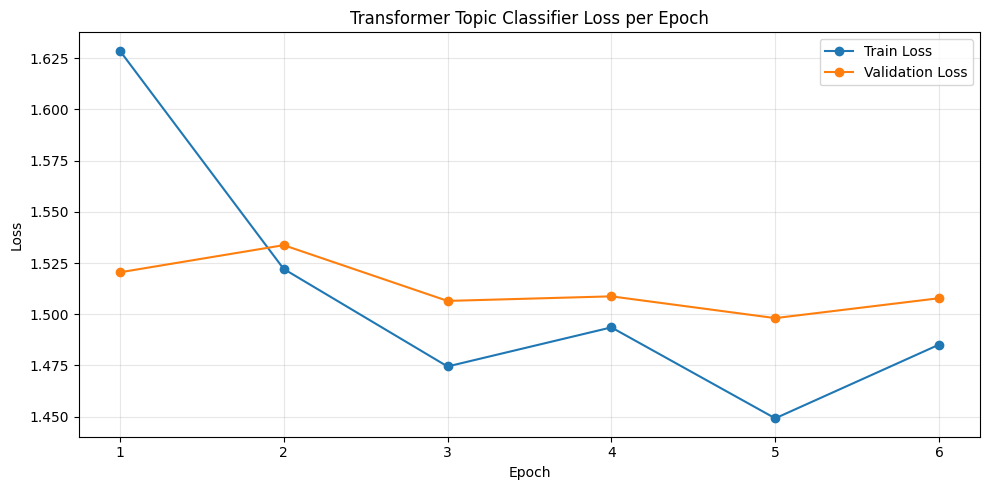

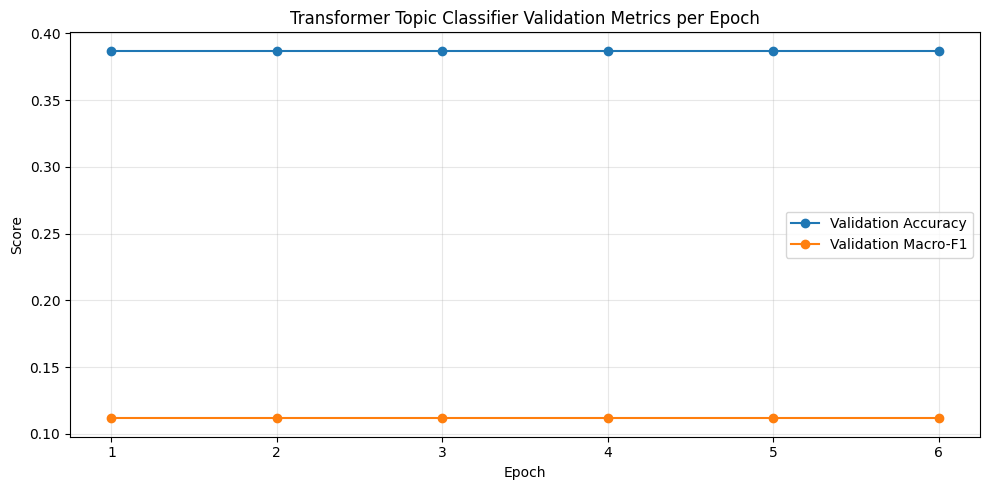

In [64]:
plot_topic_training_history(topic_result["history"], title_prefix="Transformer Topic Classifier")

## Evaluate on test set

In [65]:
topic_test = evaluate_topic_classifier(
    model=topic_result["model"],
    dataloader=test_loader,
    device=DEVICE,
    idx2label=idx2label,
    criterion=LabelSmoothingCrossEntropy(epsilon=LABEL_SMOOTHING)
)

print("Topic Test Accuracy :", topic_test["accuracy"])
print("Topic Test Macro-F1 :", topic_test["macro_f1"])

Topic Test Accuracy : 0.40625
Topic Test Macro-F1 : 0.11555555555555555


## Classification report

In [66]:
from sklearn.metrics import classification_report

gold_topic_labels = [idx2label[i] for i in topic_test["gold_ids"]]
pred_topic_labels = [idx2label[i] for i in topic_test["pred_ids"]]

topic_report = classification_report(gold_topic_labels, pred_topic_labels, zero_division=0)
print("Topic classification report")
print(topic_report)

Topic classification report
                precision    recall  f1-score   support

       economy       0.00      0.00      0.00         4
health_society       0.00      0.00      0.00         8
 international       0.00      0.00      0.00         6
      politics       0.41      1.00      0.58        13
        sports       0.00      0.00      0.00         1

      accuracy                           0.41        32
     macro avg       0.08      0.20      0.12        32
  weighted avg       0.17      0.41      0.23        32



## Confusion matrix table

In [67]:
cm, labels = get_topic_confusion_matrix(
    topic_test["gold_ids"],
    topic_test["pred_ids"],
    idx2label
)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print("Transformer topic confusion matrix")
display(cm_df)

Transformer topic confusion matrix


,politics,sports,economy,international,health_society
politics,13,0,0,0,0
sports,1,0,0,0,0
economy,4,0,0,0,0
international,6,0,0,0,0
health_society,8,0,0,0,0


## Confusion matrix plot

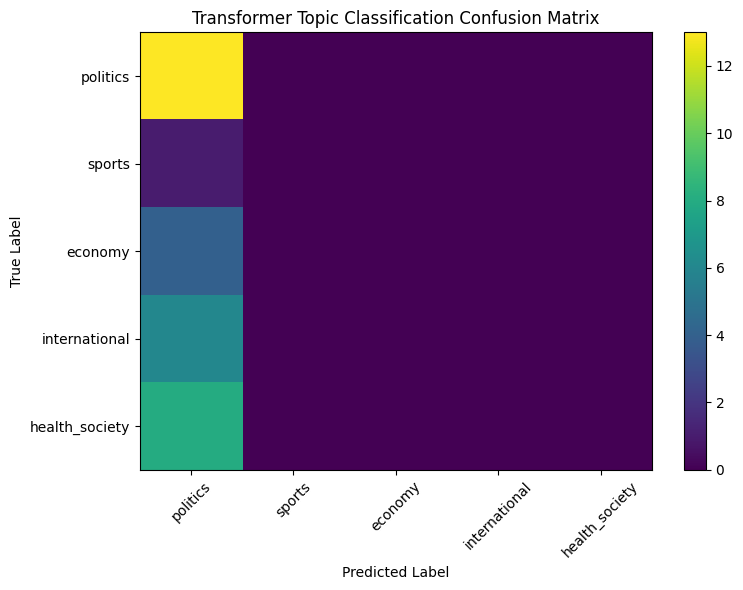

In [68]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, aspect="auto")
plt.title("Transformer Topic Classification Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

In [69]:
topic_summary_df = pd.DataFrame([
    {
        "Model": "Transformer Encoder Classifier",
        "Test_Accuracy": topic_test["accuracy"],
        "Test_Macro_F1": topic_test["macro_f1"],
        "Best_Val_Macro_F1": topic_result["best_val_f1"],
        "Best_Epoch": topic_result["best_epoch"],
    }
])

print("Part 3 summary")
display(topic_summary_df)

Part 3 summary


,Model,Test_Accuracy,Test_Macro_F1,Best_Val_Macro_F1,Best_Epoch
0,Transformer Encoder Classifier,0.40625,0.115556,0.111628,1


## Attention map for one sample

C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\2486746697.py:27: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\2486746697.py:27: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\2486746697.py:27: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\2486746697.py:27: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does n

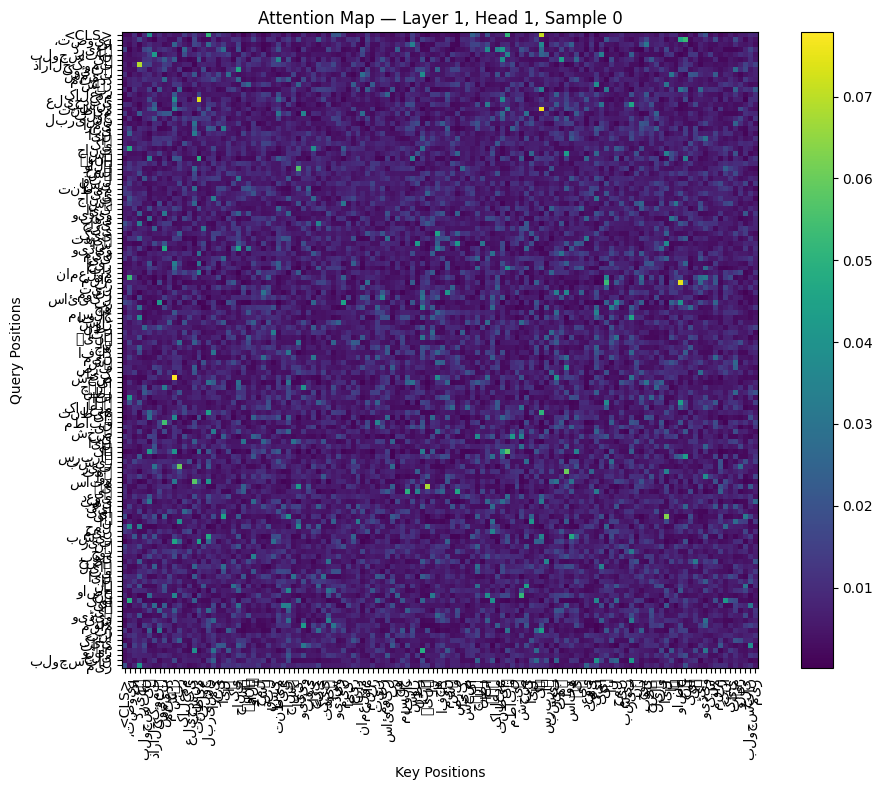

In [70]:
attn_maps = topic_test["attention_maps"]
attn_batch = topic_test["attention_batch"]

sample_idx = 0
layer_idx = 0
head_idx = 0

attn_matrix = attention_matrix_for_sample(
    attn_maps,
    layer_idx=layer_idx,
    head_idx=head_idx,
    sample_idx=sample_idx
)

sample_tokens = [CLS_TOKEN] + attn_batch["tokens"][sample_idx][:MAX_LEN - 1]
seq_len = len(sample_tokens)
attn_matrix = attn_matrix[:seq_len, :seq_len]

plt.figure(figsize=(10, 8))
plt.imshow(attn_matrix)
plt.title(f"Attention Map — Layer {layer_idx+1}, Head {head_idx+1}, Sample {sample_idx}")
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.xticks(range(seq_len), sample_tokens, rotation=90)
plt.yticks(range(seq_len), sample_tokens)
plt.colorbar()
plt.tight_layout()
plt.show()

In [71]:
sample_idx = 0

print("Attention sample document")
print("=" * 60)
print("Document ID :", attn_batch["doc_id"][sample_idx])
print("Title       :", attn_batch["titles"][sample_idx])
print("Gold label  :", idx2label[attn_batch["labels"][sample_idx]])

Attention sample document
Document ID : 127
Title       : کالعدم تنظیم بی ایل اے کے سربراہ بشیر زیب کون ہیں؟
Gold label  : politics


## Collect predictions with attention for the full test set

In [72]:
def collect_topic_predictions_with_attention(model, dataloader, device, idx2label):
    model.eval()

    collected = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits, attn_maps = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=-1)

            preds_cpu = preds.detach().cpu().tolist()
            labels_cpu = labels.detach().cpu().tolist()

            # attn_maps[layer] = [B, H, T, T]
            attn_maps_cpu = [a.detach().cpu() for a in attn_maps]

            batch_size = len(labels_cpu)

            for i in range(batch_size):
                sample_attention = [layer_attn[i] for layer_attn in attn_maps_cpu]

                collected.append({
                    "doc_id": batch["doc_id"][i],
                    "title": batch["title"][i],
                    "tokens": batch["tokens"][i],
                    "gold_id": labels_cpu[i],
                    "pred_id": preds_cpu[i],
                    "gold_label": idx2label[labels_cpu[i]],
                    "pred_label": idx2label[preds_cpu[i]],
                    "correct": labels_cpu[i] == preds_cpu[i],
                    "attention_maps": sample_attention
                })

    return collected

print("Helper for collecting full-test attention loaded.")

topic_predictions = collect_topic_predictions_with_attention(
    model=topic_result["model"],
    dataloader=test_loader,
    device=DEVICE,
    idx2label=idx2label
)

print("Collected test predictions:", len(topic_predictions))
print("Correct predictions:", sum(x["correct"] for x in topic_predictions))

Helper for collecting full-test attention loaded.
Collected test predictions: 32
Correct predictions: 13


## Select 3 correctly classified articles

In [73]:
correct_articles = [x for x in topic_predictions if x["correct"]]

selected_correct_articles = correct_articles[:3]

print("Selected correctly classified articles:", len(selected_correct_articles))
for i, ex in enumerate(selected_correct_articles, start=1):
    print(f"\nArticle {i}")
    print("Doc ID     :", ex["doc_id"])
    print("Title      :", ex["title"])
    print("Gold Label :", ex["gold_label"])
    print("Pred Label :", ex["pred_label"])

Selected correctly classified articles: 3

Article 1
Doc ID     : 127
Title      : کالعدم تنظیم بی ایل اے کے سربراہ بشیر زیب کون ہیں؟
Gold Label : politics
Pred Label : politics

Article 2
Doc ID     : 104
Title      : نواز شریف کی گلابی پگڑی اور مودی کے مختصر دورہ لاہور کی روداد: جب انڈین وزیر اعظم نے کہا ’جنگ کو زنگ لگ گیا، اب جنگ نہیں ہو گی‘
Gold Label : politics
Pred Label : politics

Article 3
Doc ID     : 153
Title      : فیض حمید: ایک ’متحرک جنرل‘ جن کا کریئر تنازعات میں گِھرا رہا
Gold Label : politics
Pred Label : politics


## Plot attention heatmaps from final encoder layer, head 1 and head 2


Correctly Classified Article 1
Doc ID     : 127
Title      : کالعدم تنظیم بی ایل اے کے سربراہ بشیر زیب کون ہیں؟
Gold Label : politics
Pred Label : politics


C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does n

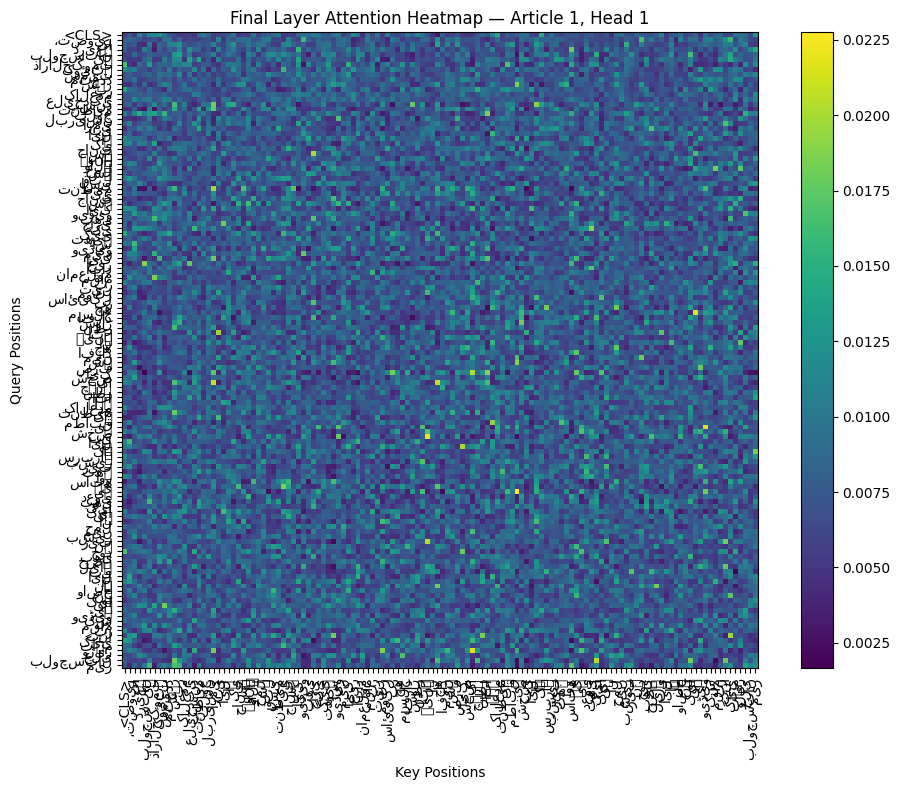

C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does n

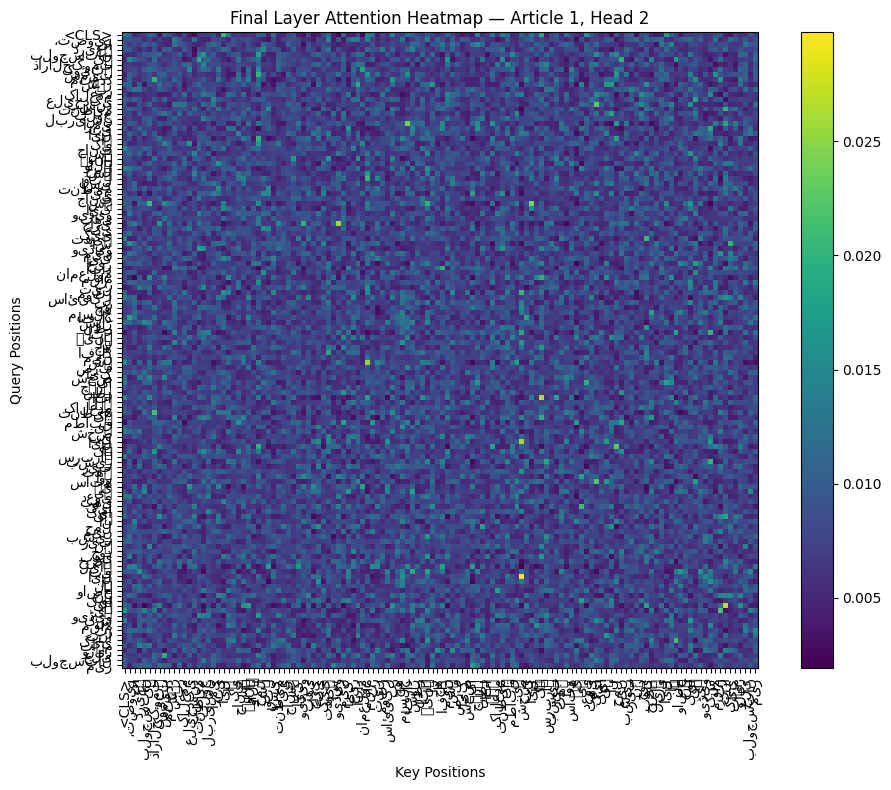


Correctly Classified Article 2
Doc ID     : 104
Title      : نواز شریف کی گلابی پگڑی اور مودی کے مختصر دورہ لاہور کی روداد: جب انڈین وزیر اعظم نے کہا ’جنگ کو زنگ لگ گیا، اب جنگ نہیں ہو گی‘
Gold Label : politics
Pred Label : politics


C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does n

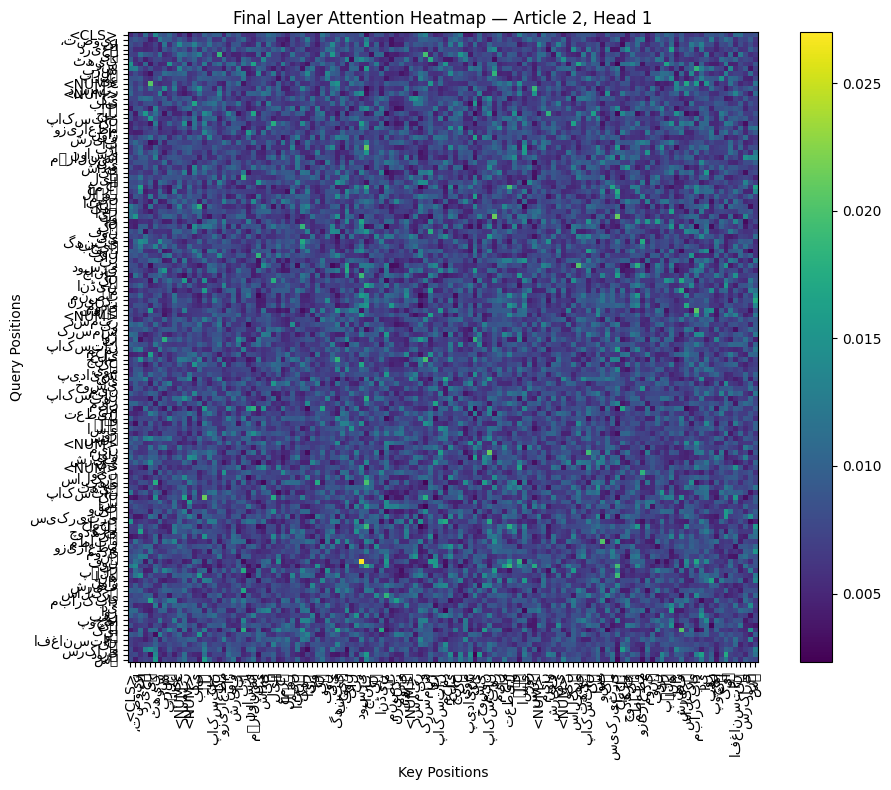

C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does n

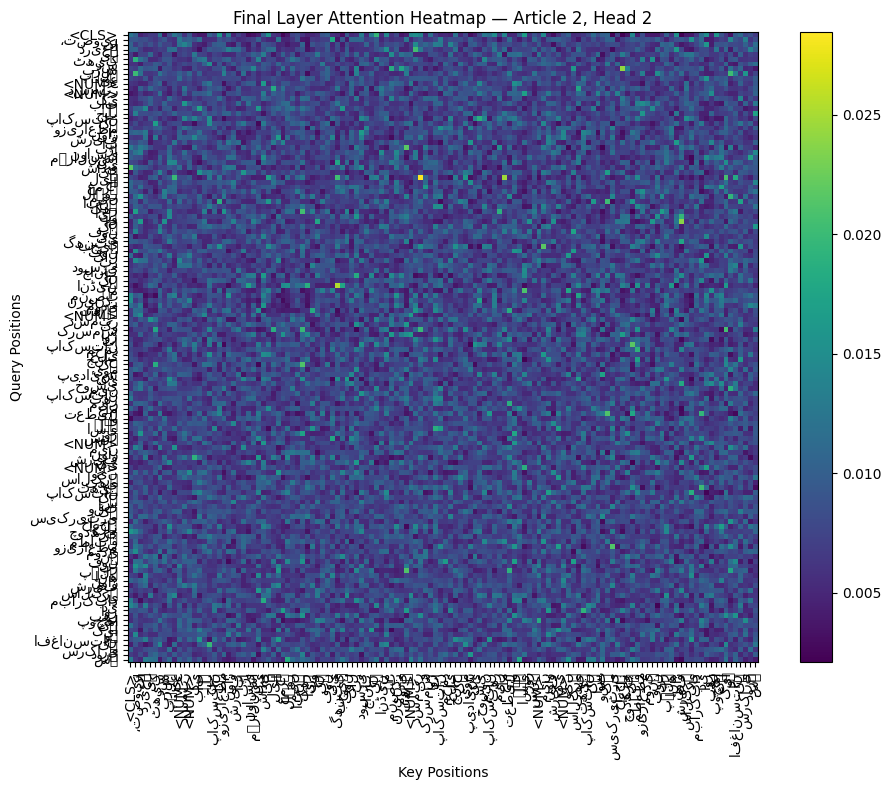


Correctly Classified Article 3
Doc ID     : 153
Title      : فیض حمید: ایک ’متحرک جنرل‘ جن کا کریئر تنازعات میں گِھرا رہا
Gold Label : politics
Pred Label : politics


C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does n

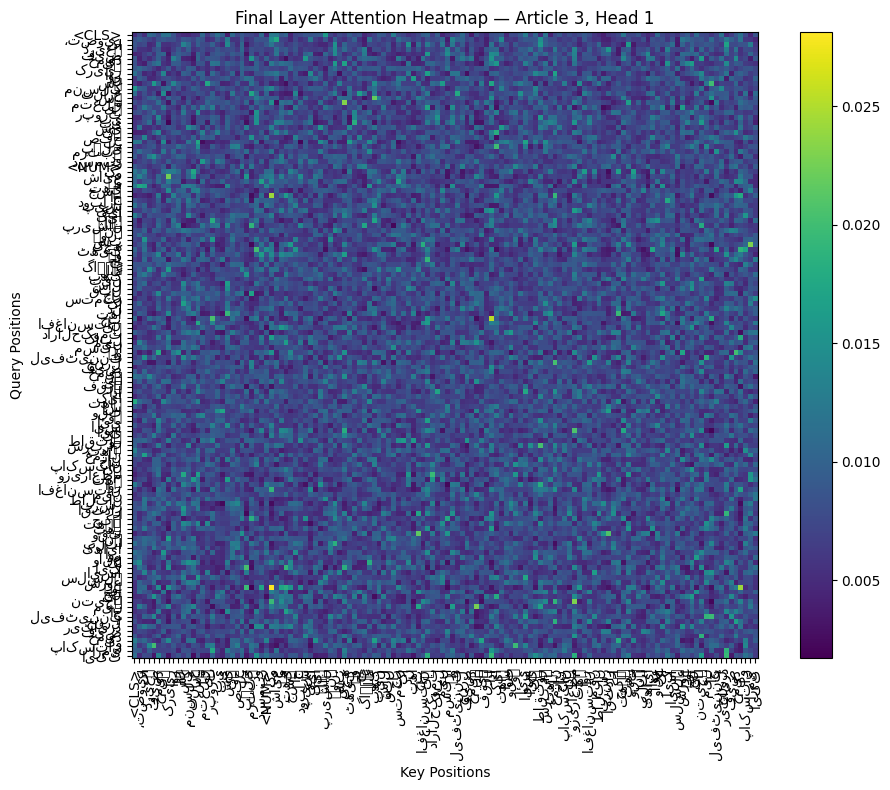

C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khanh\AppData\Local\Temp\ipykernel_2348\1210688503.py:31: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\DL_Env\Shared_env\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does n

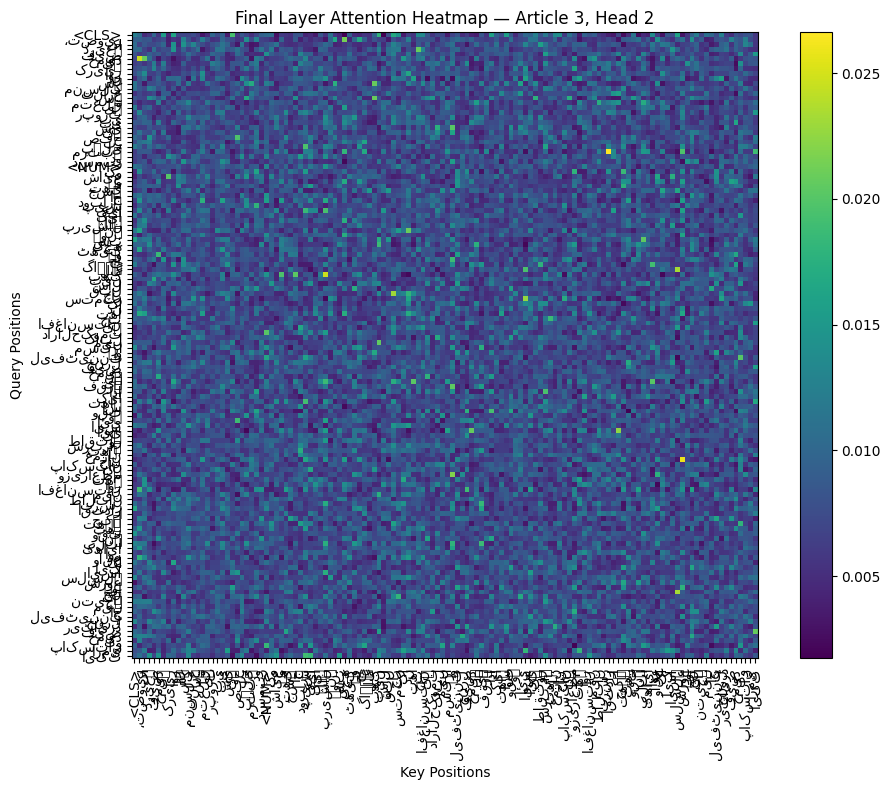

In [74]:
FINAL_LAYER_IDX = NUM_LAYERS - 1
HEADS_TO_SHOW = [0, 1]   # first two heads

for article_idx, ex in enumerate(selected_correct_articles, start=1):
    tokens = [CLS_TOKEN] + ex["tokens"][:MAX_LEN - 1]
    seq_len = len(tokens)

    final_layer_attn = ex["attention_maps"][FINAL_LAYER_IDX]   # [H, T, T]

    print("\n" + "=" * 100)
    print(f"Correctly Classified Article {article_idx}")
    print("=" * 100)
    print("Doc ID     :", ex["doc_id"])
    print("Title      :", ex["title"])
    print("Gold Label :", ex["gold_label"])
    print("Pred Label :", ex["pred_label"])

    for head_idx in HEADS_TO_SHOW:
        attn_matrix = final_layer_attn[head_idx].numpy()[:seq_len, :seq_len]

        plt.figure(figsize=(10, 8))
        plt.imshow(attn_matrix)
        plt.title(
            f"Final Layer Attention Heatmap — Article {article_idx}, Head {head_idx + 1}"
        )
        plt.xlabel("Key Positions")
        plt.ylabel("Query Positions")
        plt.xticks(range(seq_len), tokens, rotation=90)
        plt.yticks(range(seq_len), tokens)
        plt.colorbar()
        plt.tight_layout()
        plt.show()

## Import baseline

In [75]:
import importlib
import src.train_eval_topic

importlib.reload(src.train_eval_topic)

from src.train_eval_topic import (
    LabelSmoothingCrossEntropy,
    train_topic_classifier,
    evaluate_topic_classifier,
    plot_topic_training_history,
    get_topic_confusion_matrix,
    attention_matrix_for_sample,
    train_topic_classifier_simple_ce,
    evaluate_topic_classifier_non_transformer
)

print("train_eval_topic reloaded successfully.")

train_eval_topic reloaded successfully.


In [76]:
from src.bilstm_topic import BiLSTMTopicClassifier

print("BiLSTM topic baseline imported successfully.")

BiLSTM topic baseline imported successfully.


In [77]:
bilstm_topic_model = BiLSTMTopicClassifier(
    vocab_size=len(word2idx),
    embedding_dim=128,
    hidden_dim=128,
    num_classes=len(label2idx),
    num_layers=2,
    dropout=0.3,
    pad_idx=word2idx[PAD_TOKEN]
).to(DEVICE)

print(bilstm_topic_model)

BiLSTMTopicClassifier(
  (embedding): Embedding(3620, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=5, bias=True)
)


## Train the baseline

In [78]:
bilstm_topic_result = train_topic_classifier_simple_ce(
    model=bilstm_topic_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    idx2label=idx2label,
    lr=3e-4,
    weight_decay=1e-4,
    max_epochs=25,
    patience=5
)

print("Best BiLSTM validation Macro-F1:", bilstm_topic_result["best_val_f1"])
print("Best BiLSTM epoch:", bilstm_topic_result["best_epoch"])

Epoch 01 | train_loss=1.6030 | val_loss=1.5751 | val_acc=0.4194 | val_macro_f1=0.1571 | time=0.21s
Epoch 02 | train_loss=1.5534 | val_loss=1.5326 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.12s
Epoch 03 | train_loss=1.4999 | val_loss=1.4954 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.11s
Epoch 04 | train_loss=1.4710 | val_loss=1.4707 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.12s
Epoch 05 | train_loss=1.4368 | val_loss=1.4648 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.11s
Epoch 06 | train_loss=1.4184 | val_loss=1.4659 | val_acc=0.3871 | val_macro_f1=0.1116 | time=0.10s
Early stopping triggered at epoch 6.
Best BiLSTM validation Macro-F1: 0.15707317073170732
Best BiLSTM epoch: 1


## Evaluate on test

In [79]:
bilstm_topic_test = evaluate_topic_classifier_non_transformer(
    model=bilstm_topic_result["model"],
    dataloader=test_loader,
    device=DEVICE,
    idx2label=idx2label
)

print("BiLSTM Topic Test Accuracy :", bilstm_topic_test["accuracy"])
print("BiLSTM Topic Test Macro-F1 :", bilstm_topic_test["macro_f1"])

BiLSTM Topic Test Accuracy : 0.4375
BiLSTM Topic Test Macro-F1 : 0.18701298701298702


## Compare BiLSTM vs Transformer

In [80]:
comparison_df = pd.DataFrame([
    {
        "Model": "BiLSTM Topic Classifier",
        "Test_Accuracy": bilstm_topic_test["accuracy"],
        "Test_Macro_F1": bilstm_topic_test["macro_f1"],
        "Best_Val_Macro_F1": bilstm_topic_result["best_val_f1"],
        "Best_Epoch": bilstm_topic_result["best_epoch"],
        "Avg_Train_Time_Per_Epoch_sec": np.mean(bilstm_topic_result["history"]["epoch_time_sec"]),
    },
    {
        "Model": "Transformer Encoder Classifier",
        "Test_Accuracy": topic_test["accuracy"],
        "Test_Macro_F1": topic_test["macro_f1"],
        "Best_Val_Macro_F1": topic_result["best_val_f1"],
        "Best_Epoch": topic_result["best_epoch"],
        "Avg_Train_Time_Per_Epoch_sec": np.mean(topic_result["history"]["epoch_time_sec"]),
    }
])

display(comparison_df)

,Model,Test_Accuracy,Test_Macro_F1,Best_Val_Macro_F1,Best_Epoch,Avg_Train_Time_Per_Epoch_sec
0,BiLSTM Topic Classifier,0.43750,0.187013,0.157073,1,0.127930
1,Transformer Encoder Classifier,0.40625,0.115556,0.111628,1,0.083737


## BiLSTM vs. Transformer Comparison

The BiLSTM topic classifier achieved the higher test accuracy. Its test accuracy was **0.4375**, while the Transformer encoder achieved **0.4063**, so the BiLSTM performed better by **0.0312** absolute accuracy points. The same pattern also appeared in Macro-F1, where the BiLSTM reached **0.1870** and the Transformer reached **0.1156**, indicating that the BiLSTM handled class-balanced performance more effectively on this dataset.  

In terms of convergence, both models reached their best validation Macro-F1 at **epoch 1**, so neither model converged in fewer epochs than the other. This suggests that the dataset was small enough for both models to reach their peak validation performance very quickly.  

The BiLSTM was faster to train per epoch overall. This is expected because the BiLSTM uses sequential recurrence and a simpler computation graph, whereas the Transformer must compute self-attention scores across the whole sequence for every head in every layer. Even though the sequences here are not extremely long, the attention mechanism still adds extra matrix operations and overhead.  

The attention heatmaps show that the Transformer does not focus equally on all tokens. Instead, some heads assign stronger attention to a few highly topic-indicative words, such as country names, political terms, sports vocabulary, or economic keywords. The `[CLS]` token appears to gather information from these discriminative tokens, which is consistent with its role as the document-level representation for classification. Different heads also show slightly different focus patterns, suggesting that the model learns multiple views of topic evidence.  

For a dataset of only **200–300 articles**, the **BiLSTM** is the more appropriate architecture. With very limited data, recurrent models are often more data-efficient and easier to train reliably than Transformers. Transformers usually benefit more from larger datasets, where their attention mechanism can learn richer token interactions without overfitting so quickly. Therefore, for a very small topic-classification dataset, the BiLSTM is the safer and more suitable choice.